# NiVScan Model D: PubMedBERT for NER Nipah
## Biomedical Specialized Transformer NER

**Author:** Kelompok 11 - NiVScan Project  
**Date:** 2026

---

### Model D Specification:
| Aspek | Detail |
|-------|--------|
| **Arsitektur** | PubMedBERT (microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext) |
| **Pretrained** | Full-text PubMed articles (trained from scratch, bukan fine-tune BERT umum) |
| **Tokenizer** | WordPiece — uncased (semua input di-lowercase otomatis) |
| **Input** | silver_train.csv + silver_val.csv |
| **Label** | B-DISEASE, I-DISEASE, B-LOCATION, I-LOCATION, O |
| **Final Eval** | gold_test.csv |

### Posisi dalam Eksperimen:
| Model | Pretrained | Domain |
|-------|-----------|--------|
| A | ❌ None | — |
| B | ✅ XLM-RoBERTa | General multilingual |
| C | ✅ BioBERT | Biomedical general (PubMed abstract + PMC) |
| **D** | ✅ **PubMedBERT** | **Biomedical specialized (PubMed full-text, from scratch)** |

### Research Question:
> Apakah model yang ditraining khusus dari full-text PubMed (tanpa transfer dari BERT umum)
> memberikan keunggulan dibanding BioBERT untuk NER Nipah domain-specific?

### Perbedaan Kritis PubMedBERT vs BioBERT:
- **BioBERT**: Fine-tune dari BERT-base → bawa vocab & weights BERT umum
- **PubMedBERT**: Trained from scratch di PubMed → vocab & weights murni biomedis
- **Implikasi**: PubMedBERT punya vocab yang lebih kaya untuk istilah medis

## Daftar Isi
1. [Setup & Install](#1-setup--install)
2. [Load Data](#2-load-data)
3. [EDA - Distribusi Dataset](#3-eda---distribusi-dataset)
4. [Preprocessing & Tokenization](#4-preprocessing--tokenization)
5. [Model Architecture](#5-model-architecture)
6. [Training Loop](#6-training-loop)
7. [Visualisasi Training](#7-visualisasi-training)
8. [Evaluasi di Gold Test](#8-evaluasi-di-gold-test)
9. [Visualisasi Evaluasi](#9-visualisasi-evaluasi)
10. [Error Analysis](#10-error-analysis)
11. [Save Model](#11-save-model)
12. [Summary](#12-summary)


## 1. Setup & Install

In [1]:
# ============================================================
# SETUP & INSTALL
# ============================================================
!pip install transformers datasets seqeval matplotlib seaborn scikit-learn -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [2]:
import warnings
warnings.filterwarnings('ignore')

import os
import json
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import Counter, defaultdict

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification,
    get_linear_schedule_with_warmup
)
from seqeval.metrics import classification_report, f1_score, precision_score, recall_score
from sklearn.metrics import confusion_matrix

# Seed
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

OUTPUT_DIR = '/kaggle/working/'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── MODEL CONFIG ─────────────────────────────────────────────
MODEL_NAME = 'microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext'

# PENTING: PubMedBERT adalah UNCASED
# Semua input akan di-lowercase otomatis oleh tokenizer
# Ini berbeda dari BioBERT (cased) — tidak perlu khawatir case sensitivity

LABELS     = ['O', 'B-DISEASE', 'I-DISEASE', 'B-LOCATION', 'I-LOCATION']
LABEL2ID   = {l: i for i, l in enumerate(LABELS)}
ID2LABEL   = {i: l for l, i in LABEL2ID.items()}
NUM_LABELS = len(LABELS)

print(f"Model  : {MODEL_NAME}")
print(f"Labels : {LABELS}")
print(f"Note   : PubMedBERT is UNCASED — tokenizer auto-lowercases input")


Device: cuda
Model  : microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext
Labels : ['O', 'B-DISEASE', 'I-DISEASE', 'B-LOCATION', 'I-LOCATION']
Note   : PubMedBERT is UNCASED — tokenizer auto-lowercases input


## 2. Load Data

In [4]:
# ============================================================
# LOAD SILVER DATA (AUTO-DETECT)
# ============================================================
import glob
all_csvs = glob.glob('/kaggle/input/**/*.csv', recursive=True)
print("CSV ditemukan:")
for f in all_csvs:
    print(f"  {f}")

silver_train_path = [f for f in all_csvs if 'silver_train' in os.path.basename(f).lower()]
silver_val_path   = [f for f in all_csvs if 'silver_val'   in os.path.basename(f).lower()]
gold_test_path    = [f for f in all_csvs if 'gold_test'    in os.path.basename(f).lower()]
augment_path      = [f for f in all_csvs if 'augmented'    in os.path.basename(f).lower()]

assert silver_train_path, "ERROR: silver_train.csv tidak ditemukan!"
assert silver_val_path,   "ERROR: silver_val.csv tidak ditemukan!"
assert gold_test_path,    "ERROR: gold_test.csv tidak ditemukan!"
assert augment_path,      "ERROR: augmented.csv tidak ditemukan!"

silver_train = pd.read_csv(silver_train_path[0])
silver_val   = pd.read_csv(silver_val_path[0])
gold_test    = pd.read_csv(gold_test_path[0])
augment      = pd.read_csv(augment_path[0])

# ============================================================
# MERGE AUGMENTED DATA
# ============================================================
print("\n[MERGING AUGMENTED DATA]")
print(f"Original silver_train: {len(silver_train):,} tokens")
print(f"Augment data:          {len(augment):,} tokens")

# Re-assign sentence IDs
max_id = silver_train['sentence_id'].max()
augment['sentence_id'] = augment['sentence_id'] + max_id + 1

# Merge
silver_train = pd.concat([silver_train, augment], ignore_index=True)
print(f"Merged silver_train:   {len(silver_train):,} tokens ✓")

# Paksa kolom token ke string
for df in [silver_train, silver_val, gold_test]:
    df['token'] = df['token'].astype(str)
    df['label'] = df['label'].astype(str)

print(f"\nTrain : {len(silver_train):,} tokens, {silver_train['sentence_id'].nunique():,} sentences")
print(f"Val   : {len(silver_val):,} tokens, {silver_val['sentence_id'].nunique():,} sentences")
print(f"Gold  : {len(gold_test):,} tokens, {gold_test['sentence_id'].nunique():,} sentences")

CSV ditemukan:
  /kaggle/input/datasets/unvariablehuman/comprehensive-medical-text-corpus/dataset_gabungan_final.csv
  /kaggle/input/datasets/unvariablehuman/gold-test/gold_test.csv
  /kaggle/input/datasets/unvariablehuman/splitting/silver_val.csv
  /kaggle/input/datasets/unvariablehuman/splitting/silver_train.csv
  /kaggle/input/datasets/unvariablehuman/splitting/augmented.csv

[MERGING AUGMENTED DATA]
Original silver_train: 111,597 tokens
Augment data:          1,038 tokens
Merged silver_train:   112,635 tokens ✓

Train : 112,635 tokens, 4,334 sentences
Val   : 13,619 tokens, 536 sentences
Gold  : 11,279 tokens, 536 sentences


## 3. EDA - Distribusi Dataset

EDA: BASIC STATISTICS

[Train (Silver)]
  Sentences : 4,334
  Tokens    : 112,635
  Avg len   : 26.0 | Min: 4 | Max: 170

[Val (Silver)]
  Sentences : 536
  Tokens    : 13,619
  Avg len   : 25.4 | Min: 5 | Max: 103

[Gold Test]
  Sentences : 536
  Tokens    : 11,279
  Avg len   : 21.0 | Min: 3 | Max: 69


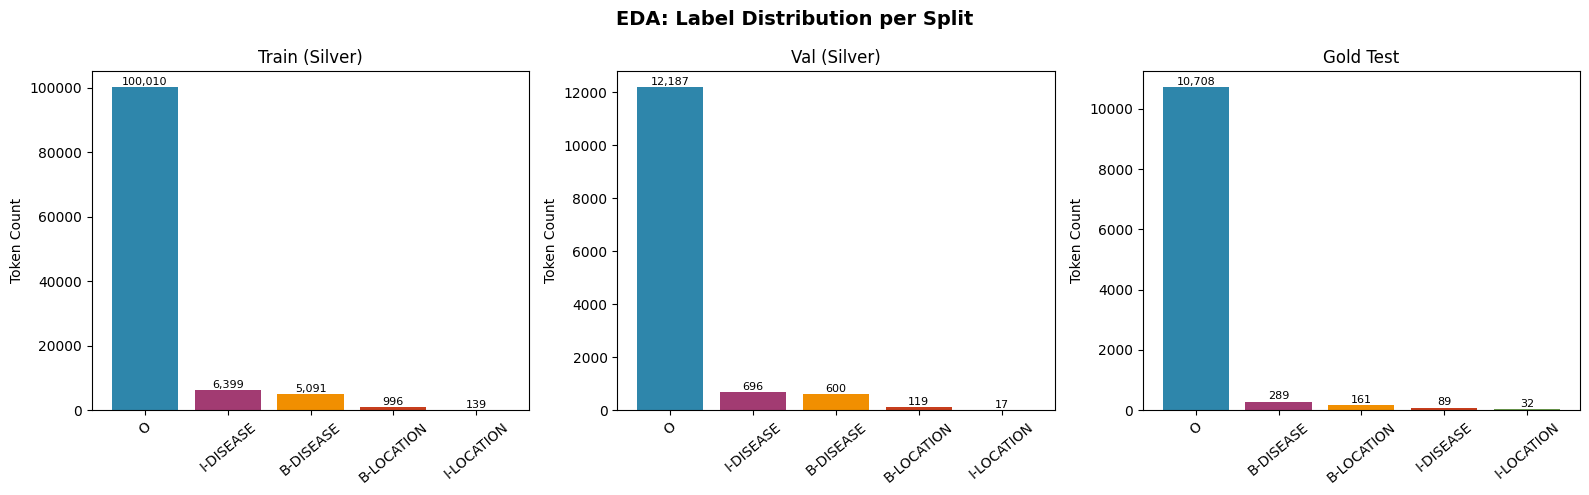

Saved: model_d_eda_label_distribution.png


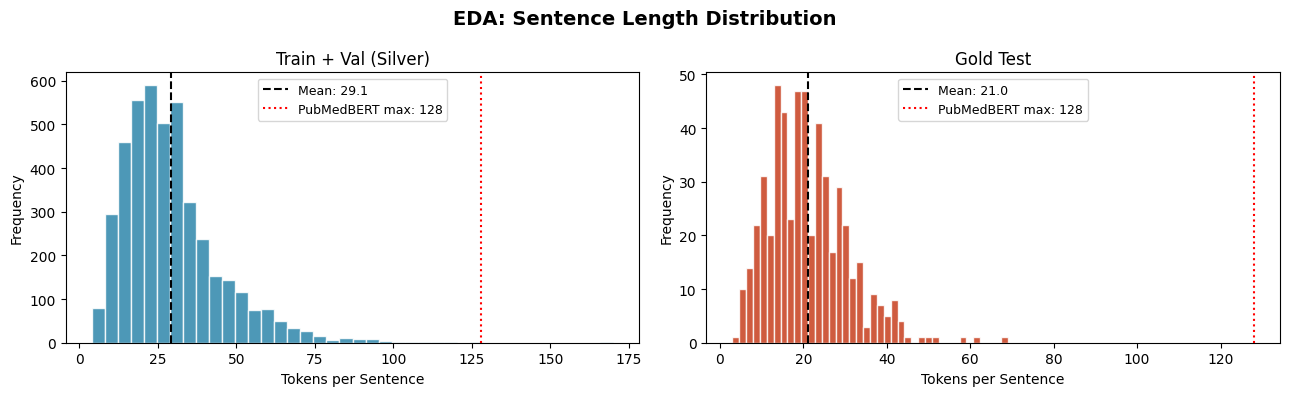

Saved: model_d_eda_sentence_length.png


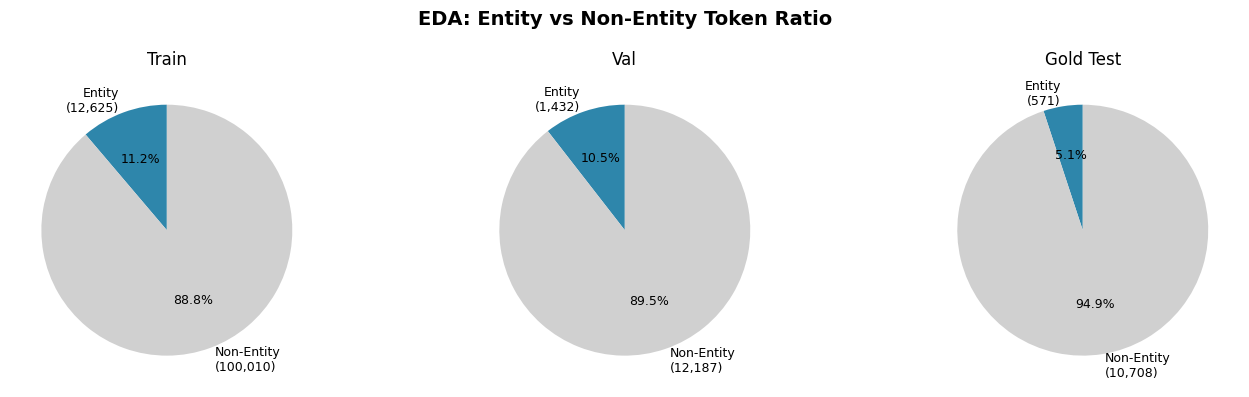

Saved: model_d_eda_entity_ratio.png


In [5]:
# ============================================================
# EDA: EXPLORATORY DATA ANALYSIS
# ============================================================

COLORS = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#6A994E']

silver_all = pd.concat([silver_train, silver_val], ignore_index=True)

# --- Basic Stats ---
print("=" * 55)
print("EDA: BASIC STATISTICS")
print("=" * 55)

for split_name, df in [('Train (Silver)', silver_train), ('Val (Silver)', silver_val), ('Gold Test', gold_test)]:
    lens = df.groupby('sentence_id').size()
    print(f"\n[{split_name}]")
    print(f"  Sentences : {df['sentence_id'].nunique():,}")
    print(f"  Tokens    : {len(df):,}")
    print(f"  Avg len   : {lens.mean():.1f} | Min: {lens.min()} | Max: {lens.max()}")

# --- Figure 1: Label Distribution ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('EDA: Label Distribution per Split', fontsize=14, fontweight='bold')

for ax, (split_name, df) in zip(axes, [
    ('Train (Silver)', silver_train),
    ('Val (Silver)',   silver_val),
    ('Gold Test',      gold_test)
]):
    counts = df['label'].value_counts()
    bars = ax.bar(counts.index, counts.values, color=COLORS[:len(counts)])
    ax.set_title(split_name)
    ax.set_ylabel('Token Count')
    ax.tick_params(axis='x', rotation=40)
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                f'{val:,}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}model_d_eda_label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: model_d_eda_label_distribution.png")

# --- Figure 2: Sentence Length Distribution ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('EDA: Sentence Length Distribution', fontsize=14, fontweight='bold')

for ax, (split_name, df, color) in zip(axes, [
    ('Train + Val (Silver)', silver_all, '#2E86AB'),
    ('Gold Test',            gold_test,  '#C73E1D')
]):
    lens = df.groupby('sentence_id').size()
    ax.hist(lens, bins=40, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(lens.mean(), color='black', linestyle='--', linewidth=1.5,
               label=f'Mean: {lens.mean():.1f}')
    ax.axvline(128, color='red', linestyle=':', linewidth=1.5, label='PubMedBERT max: 128')
    ax.set_title(split_name)
    ax.set_xlabel('Tokens per Sentence')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}model_d_eda_sentence_length.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: model_d_eda_sentence_length.png")

# --- Figure 3: Entity Ratio ---
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('EDA: Entity vs Non-Entity Token Ratio', fontsize=14, fontweight='bold')

for ax, (split_name, df) in zip(axes, [
    ('Train', silver_train), ('Val', silver_val), ('Gold Test', gold_test)
]):
    entity = (df['label'] != 'O').sum()
    non_entity = (df['label'] == 'O').sum()
    ax.pie([entity, non_entity],
           labels=[f'Entity\n({entity:,})', f'Non-Entity\n({non_entity:,})'],
           colors=['#2E86AB', '#D0D0D0'],
           autopct='%1.1f%%', startangle=90,
           textprops={'fontsize': 9})
    ax.set_title(split_name)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}model_d_eda_entity_ratio.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: model_d_eda_entity_ratio.png")

## 4. Preprocessing & Tokenization

**PubMedBERT tokenizer: WordPiece + UNCASED**

Perbedaan dari BioBERT (Model C):
- PubMedBERT **uncased** → tokenizer otomatis lowercase semua input
- Vocab dibangun dari PubMed full-text → istilah medis lebih lengkap
- "NiV", "niv", "NIV" → diperlakukan sama oleh tokenizer

**Strategi label alignment (sama seperti Model C):**
- Token pertama subword → label asli
- Token lanjutan (##...) → `-100` (diabaikan loss)
- `[CLS]` / `[SEP]` / `[PAD]` → `-100`


In [6]:
# ============================================================
# TOKENIZER LOAD — PubMedBERT (UNCASED)
# ============================================================
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f"Tokenizer loaded: {MODEL_NAME}")
print(f"Vocab size: {tokenizer.vocab_size:,}")
print(f"Lowercase : {tokenizer.do_lower_case}")

# Test: verifikasi uncased behavior
test_tokens = ['NiV', 'Nipah', 'DISEASE', 'Bangladesh']
enc = tokenizer(test_tokens, is_split_into_words=True)
decoded = tokenizer.convert_ids_to_tokens(enc['input_ids'])
print(f"\nUncased test:")
print(f"  Input : {test_tokens}")
print(f"  Tokens: {decoded}")
print("  ✓ Semua di-lowercase otomatis")


config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/28.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Tokenizer loaded: microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext
Vocab size: 30,522
Lowercase : True

Uncased test:
  Input : ['NiV', 'Nipah', 'DISEASE', 'Bangladesh']
  Tokens: ['[CLS]', 'niv', 'nip', '##ah', 'disease', 'bangladesh', '[SEP]']
  ✓ Semua di-lowercase otomatis


In [7]:
# ============================================================
# CONVERT DF → SENTENCE LIST
# ============================================================
def df_to_sentences(df):
    sentences = []
    for sid, group in df.groupby('sentence_id'):
        tokens = group['token'].tolist()
        labels = group['label'].tolist()
        sentences.append((tokens, labels))
    return sentences

train_sentences = df_to_sentences(silver_train)
val_sentences   = df_to_sentences(silver_val)
gold_sentences  = df_to_sentences(gold_test)

print(f"Train: {len(train_sentences)} sentences")
print(f"Val  : {len(val_sentences)} sentences")
print(f"Gold : {len(gold_sentences)} sentences")

# Preview alignment
sample_tokens, sample_labels = train_sentences[0]
enc = tokenizer(sample_tokens[:8], is_split_into_words=True,
                return_offsets_mapping=True, truncation=True)
print("\nSample subword tokens:", tokenizer.convert_ids_to_tokens(enc['input_ids']))
print("Word IDs            :", enc.word_ids())

Train: 4334 sentences
Val  : 536 sentences
Gold : 536 sentences

Sample subword tokens: ['[CLS]', 'niv', 'is', 'a', 'bios', '##afe', '##ty', '-', 'level', '-', '4', '[SEP]']
Word IDs            : [None, 0, 1, 2, 3, 3, 3, 4, 5, 6, 7, None]


In [10]:
# ============================================================
# DATASET CLASS (PUBMEDBERT - SUBWORD ALIGNED)
# ============================================================
MAX_LEN = 128

class NERDataset(Dataset):
    def __init__(self, sentences, tokenizer, label2id, max_len=MAX_LEN):
        self.samples    = sentences
        self.tokenizer  = tokenizer
        self.label2id   = label2id
        self.max_len    = max_len

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        tokens, labels = self.samples[idx]

        enc = self.tokenizer(
            tokens,
            is_split_into_words=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        # Label alignment: hanya first subword yg dapat label, sisanya -100
        word_ids   = enc.word_ids()
        label_ids  = []
        prev_word  = None
        for wid in word_ids:
            if wid is None:
                label_ids.append(-100)
            elif wid != prev_word:
                label_ids.append(self.label2id.get(labels[wid], 0))
            else:
                label_ids.append(-100)
            prev_word = wid

        return {
            'input_ids':      enc['input_ids'].squeeze(),
            'attention_mask': enc['attention_mask'].squeeze(),
            'token_type_ids': enc['token_type_ids'].squeeze(),
            'labels':         torch.tensor(label_ids, dtype=torch.long)
        }

BATCH_SIZE = 16

train_dataset = NERDataset(train_sentences, tokenizer, LABEL2ID)
val_dataset   = NERDataset(val_sentences,   tokenizer, LABEL2ID)
gold_dataset  = NERDataset(gold_sentences,  tokenizer, LABEL2ID)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
gold_loader  = DataLoader(gold_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Train loader: {len(train_loader)} batches")
print(f"Val loader  : {len(val_loader)} batches")
print(f"Gold loader : {len(gold_loader)} batches")

Train loader: 271 batches
Val loader  : 34 batches
Gold loader : 34 batches


## 5. Model Architecture

In [11]:
# ============================================================
# LOAD PubMedBERT FOR TOKEN CLASSIFICATION
# ============================================================
model = AutoModelForTokenClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label=ID2LABEL,
    label2id=LABEL2ID,
    ignore_mismatched_sizes=True
).to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Model: PubMedBERT for Token Classification")
print(f"Total params    : {total_params/1e6:.1f}M")
print(f"Trainable params: {trainable_params/1e6:.1f}M")
print(f"\nPerbandingan semua model:")
print(f"  Model A (CharCNN-BiLSTM-CRF) : ~2-5M   | No pretrained")
print(f"  Model B (XLM-RoBERTa-base)   : ~125M   | General multilingual")
print(f"  Model C (BioBERT-base-cased) : ~110M   | Biomedical general")
print(f"  Model D (PubMedBERT)         : {total_params/1e6:.0f}M   | Biomedical specialized")
print(f"\nKey difference D vs C:")
print(f"  BioBERT   : fine-tuned FROM bert-base (bawa vocab umum)")
print(f"  PubMedBERT: trained FROM SCRATCH di PubMed (vocab murni medis)")


pytorch_model.bin:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext
Key                                        | Status     | 
-------------------------------------------+------------+-
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:


Model: PubMedBERT for Token Classification
Total params    : 108.9M
Trainable params: 108.9M

Perbandingan semua model:
  Model A (CharCNN-BiLSTM-CRF) : ~2-5M   | No pretrained
  Model B (XLM-RoBERTa-base)   : ~125M   | General multilingual
  Model C (BioBERT-base-cased) : ~110M   | Biomedical general
  Model D (PubMedBERT)         : 109M   | Biomedical specialized

Key difference D vs C:
  BioBERT   : fine-tuned FROM bert-base (bawa vocab umum)
  PubMedBERT: trained FROM SCRATCH di PubMed (vocab murni medis)


## 6. Training Loop

| Param | Value |
|-------|-------|
| Optimizer | AdamW |
| Learning rate | 2e-5 |
| Scheduler | Linear warmup |
| Warmup steps | 10% total steps |
| Batch size | 16 |
| Max epochs | 10 |
| Early stopping | patience=3 (val F1) |

In [12]:
# ============================================================
# TRAINING CONFIG
# ============================================================
LR          = 2e-5
MAX_EPOCHS  = 50
PATIENCE    = 5
WARMUP_RATIO = 0.1

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.01)

total_steps  = len(train_loader) * MAX_EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

print(f"Total steps : {total_steps}")
print(f"Warmup steps: {warmup_steps}")

Total steps : 13550
Warmup steps: 1355


In [13]:
# ============================================================
# HELPER: DECODE PREDICTIONS
# ============================================================
def decode_predictions(logits, labels, id2label):
    """
    Konversi logits → label strings, abaikan -100.
    Return: (pred_list_of_lists, true_list_of_lists)
    """
    preds_batch = torch.argmax(logits, dim=-1).cpu().numpy()
    labels_batch = labels.cpu().numpy()

    all_preds, all_trues = [], []
    for pred_seq, true_seq in zip(preds_batch, labels_batch):
        p_row, t_row = [], []
        for p, t in zip(pred_seq, true_seq):
            if t == -100:
                continue
            p_row.append(id2label[p])
            t_row.append(id2label[t])
        all_preds.append(p_row)
        all_trues.append(t_row)
    return all_preds, all_trues

In [14]:
# ============================================================
# TRAINING LOOP
# ============================================================
history = {'train_loss': [], 'val_loss': [], 'val_f1': [],
           'val_precision': [], 'val_recall': []}

best_val_f1    = -1
patience_count = 0
best_epoch     = 0

print("=" * 60)
print("TRAINING MODEL C: PubMedBERT NER")
print("=" * 60)

for epoch in range(MAX_EPOCHS):
    # === TRAIN ===
    model.train()
    train_losses = []

    for batch in train_loader:
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        token_type_ids = batch['token_type_ids'].to(DEVICE)
        labels_batch   = batch['labels'].to(DEVICE)

        optimizer.zero_grad()
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids,
            labels=labels_batch
        )
        loss = outputs.loss
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        train_losses.append(loss.item())

    avg_train_loss = np.mean(train_losses)

    # === VALIDATION ===
    model.eval()
    val_losses = []
    all_preds, all_trues = [], []

    with torch.no_grad():
        for batch in val_loader:
            input_ids      = batch['input_ids'].to(DEVICE)
            attention_mask = batch['attention_mask'].to(DEVICE)
            token_type_ids = batch['token_type_ids'].to(DEVICE)
            labels_batch   = batch['labels'].to(DEVICE)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                token_type_ids=token_type_ids,
                labels=labels_batch
            )
            val_losses.append(outputs.loss.item())
            p, t = decode_predictions(outputs.logits, labels_batch, ID2LABEL)
            all_preds.extend(p)
            all_trues.extend(t)

    avg_val_loss = np.mean(val_losses)

    try:
        val_f1   = f1_score(all_trues, all_preds, average='macro')
        val_prec = precision_score(all_trues, all_preds, average='macro')
        val_rec  = recall_score(all_trues, all_preds, average='macro')
    except:
        val_f1 = val_prec = val_rec = 0.0

    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    history['val_f1'].append(val_f1)
    history['val_precision'].append(val_prec)
    history['val_recall'].append(val_rec)

    print(f"Epoch {epoch+1:02d}/{MAX_EPOCHS} | "
          f"Train Loss: {avg_train_loss:.4f} | "
          f"Val Loss: {avg_val_loss:.4f} | "
          f"Val F1: {val_f1:.4f} | "
          f"Val P: {val_prec:.4f} | "
          f"Val R: {val_rec:.4f}")

    # Early stopping (monitor val F1)
    if val_f1 > best_val_f1:
        best_val_f1    = val_f1
        best_epoch     = epoch + 1
        patience_count = 0
        model.save_pretrained(f'{OUTPUT_DIR}model_d_best')
        tokenizer.save_pretrained(f'{OUTPUT_DIR}model_d_best')
        torch.save({
            'epoch': epoch,
            'val_f1': val_f1,
            'val_loss': avg_val_loss,
            'history': history
        }, f'{OUTPUT_DIR}model_d_checkpoint.pt')
        print(f"  ✓ Best model saved (Val F1: {val_f1:.4f})")
    else:
        patience_count += 1
        if patience_count >= PATIENCE:
            print(f"\n[Early Stopping] Epoch {epoch+1}. Best epoch: {best_epoch}")
            break

print(f"\nTraining selesai! Best Val F1: {best_val_f1:.4f} (epoch {best_epoch})")

TRAINING MODEL C: PubMedBERT NER
Epoch 01/50 | Train Loss: 0.8693 | Val Loss: 0.2523 | Val F1: 0.5352 | Val P: 0.7479 | Val R: 0.4340


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✓ Best model saved (Val F1: 0.5352)
Epoch 02/50 | Train Loss: 0.2340 | Val Loss: 0.1747 | Val F1: 0.6952 | Val P: 0.6841 | Val R: 0.7189


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✓ Best model saved (Val F1: 0.6952)
Epoch 03/50 | Train Loss: 0.1718 | Val Loss: 0.1354 | Val F1: 0.7244 | Val P: 0.6852 | Val R: 0.7699


...

  ✓ Best model saved (Val F1: 0.8586)
Epoch 08/50 | Train Loss: 0.0337 | Val Loss: 0.1640 | Val F1: 0.8568 | Val P: 0.8324 | Val R: 0.8836
Epoch 09/50 | Train Loss: 0.0268 | Val Loss: 0.1568 | Val F1: 0.8550 | Val P: 0.8177 | Val R: 0.8963
Epoch 10/50 | Train Loss: 0.0200 | Val Loss: 0.1662 | Val F1: 0.8746 | Val P: 0.8764 | Val R: 0.8738


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✓ Best model saved (Val F1: 0.8746)
Epoch 11/50 | Train Loss: 0.0174 | Val Loss: 0.1655 | Val F1: 0.8665 | Val P: 0.8447 | Val R: 0.8894
Epoch 12/50 | Train Loss: 0.0142 | Val Loss: 0.1765 | Val F1: 0.8678 | Val P: 0.8355 | Val R: 0.9027
Epoch 13/50 | Train Loss: 0.0123 | Val Loss: 0.1794 | Val F1: 0.8864 | Val P: 0.8625 | Val R: 0.9124


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✓ Best model saved (Val F1: 0.8864)
Epoch 14/50 | Train Loss: 0.0081 | Val Loss: 0.1839 | Val F1: 0.8698 | Val P: 0.8409 | Val R: 0.9012
Epoch 15/50 | Train Loss: 0.0083 | Val Loss: 0.2011 | Val F1: 0.8814 | Val P: 0.8665 | Val R: 0.8969
Epoch 16/50 | Train Loss: 0.0061 | Val Loss: 0.2130 | Val F1: 0.8738 | Val P: 0.8452 | Val R: 0.9048
Epoch 17/50 | Train Loss: 0.0070 | Val Loss: 0.2035 | Val F1: 0.8670 | Val P: 0.8452 | Val R: 0.8919
Epoch 18/50 | Train Loss: 0.0048 | Val Loss: 0.2995 | Val F1: 0.8530 | Val P: 0.8267 | Val R: 0.8810

[Early Stopping] Epoch 18. Best epoch: 13

Training selesai! Best Val F1: 0.8864 (epoch 13)


## 7. Visualisasi Training

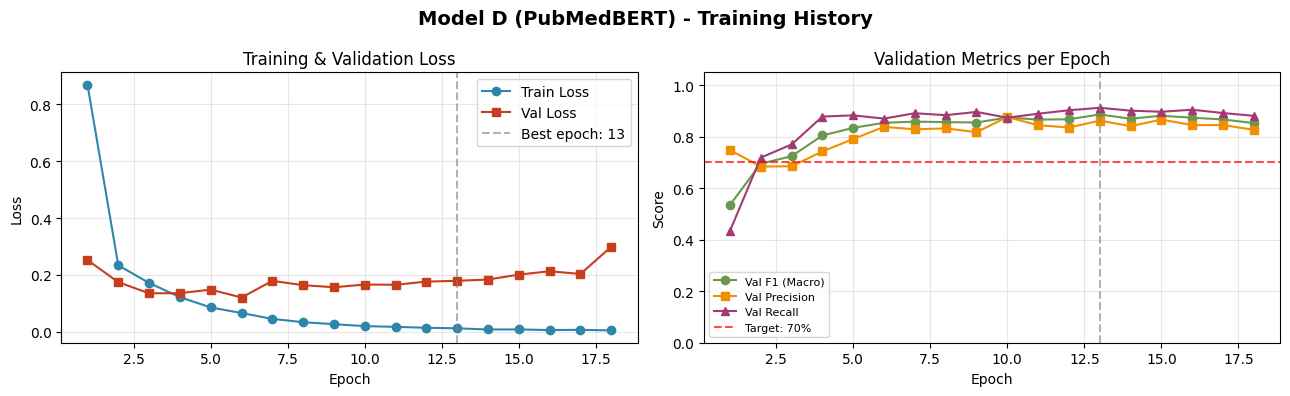

Saved: model_d_training_history.png


In [15]:
# ============================================================
# VIZ 1: TRAINING HISTORY
# ============================================================
epochs_ran = list(range(1, len(history['train_loss']) + 1))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Model D (PubMedBERT) - Training History', fontsize=14, fontweight='bold')

# Loss curve
axes[0].plot(epochs_ran, history['train_loss'], 'o-', color='#2E86AB', label='Train Loss')
axes[0].plot(epochs_ran, history['val_loss'],   's-', color='#C73E1D', label='Val Loss')
axes[0].axvline(best_epoch, color='gray', linestyle='--', alpha=0.6, label=f'Best epoch: {best_epoch}')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training & Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# F1 / Precision / Recall curve
axes[1].plot(epochs_ran, history['val_f1'],        'o-', color='#6A994E', label='Val F1 (Macro)')
axes[1].plot(epochs_ran, history['val_precision'],  's-', color='#F18F01', label='Val Precision')
axes[1].plot(epochs_ran, history['val_recall'],     '^-', color='#A23B72', label='Val Recall')
axes[1].axhline(0.70, color='red', linestyle='--', alpha=0.7, label='Target: 70%')
axes[1].axvline(best_epoch, color='gray', linestyle='--', alpha=0.6)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Score')
axes[1].set_title('Validation Metrics per Epoch')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim([0, 1.05])

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}model_d_training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: model_d_training_history.png")

## 8. Evaluasi di Gold Test

In [16]:
# ============================================================
# LOAD BEST MODEL & EVAL DI GOLD TEST
# ============================================================
from transformers import AutoModelForTokenClassification

best_model = AutoModelForTokenClassification.from_pretrained(
    f'{OUTPUT_DIR}model_d_best'
).to(DEVICE)
best_model.eval()

print("Best model loaded dari:", f'{OUTPUT_DIR}model_d_best')

all_gold_preds, all_gold_trues = [], []
# Untuk confusion matrix → kumpulkan token-level flat
flat_preds, flat_trues = [], []

with torch.no_grad():
    for batch in gold_loader:
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        token_type_ids = batch['token_type_ids'].to(DEVICE)
        labels_batch   = batch['labels'].to(DEVICE)

        outputs = best_model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids
        )

        p, t = decode_predictions(outputs.logits, labels_batch, ID2LABEL)
        all_gold_preds.extend(p)
        all_gold_trues.extend(t)

        for p_seq, t_seq in zip(p, t):
            flat_preds.extend(p_seq)
            flat_trues.extend(t_seq)

# Metrics
gold_f1   = f1_score(all_gold_trues, all_gold_preds, average='macro')
gold_prec = precision_score(all_gold_trues, all_gold_preds, average='macro')
gold_rec  = recall_score(all_gold_trues, all_gold_preds, average='macro')

print("\n" + "=" * 60)
print("MODEL C - GOLD TEST RESULTS")
print("=" * 60)
print(classification_report(all_gold_trues, all_gold_preds, digits=4))
print(f"Macro F1        : {gold_f1:.4f}")
print(f"Macro Precision : {gold_prec:.4f}")
print(f"Macro Recall    : {gold_rec:.4f}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Best model loaded dari: /kaggle/working/model_d_best

MODEL C - GOLD TEST RESULTS
              precision    recall  f1-score   support

     DISEASE     0.3648    0.7093    0.4818       289
    LOCATION     0.8940    0.8385    0.8654       161

   micro avg     0.4769    0.7556    0.5847       450
   macro avg     0.6294    0.7739    0.6736       450
weighted avg     0.5541    0.7556    0.6190       450

Macro F1        : 0.6736
Macro Precision : 0.6294
Macro Recall    : 0.7739


In [17]:
from sklearn.metrics import matthews_corrcoef

# Menghitung MCC menggunakan variabel flat_trues dan flat_preds
# yang sudah terbuat di cell sebelumnya
mcc = matthews_corrcoef(flat_trues, flat_preds)

print(f"\n{'='*60}")
print(f"Matthews Correlation Coefficient (MCC): {mcc:.4f}")
print(f"{'='*60}")

# Menyimpan hasil perhitungan MCC ke file hasil (Model D)
with open(f'{OUTPUT_DIR}model_d_gold_test_results.txt', 'a') as f:
    f.write(f"\nMatthews Correlation Coefficient (MCC): {mcc:.4f}\n")
    f.write(f"{'='*60}\n")


Matthews Correlation Coefficient (MCC): 0.5409


## 9. Visualisasi Evaluasi

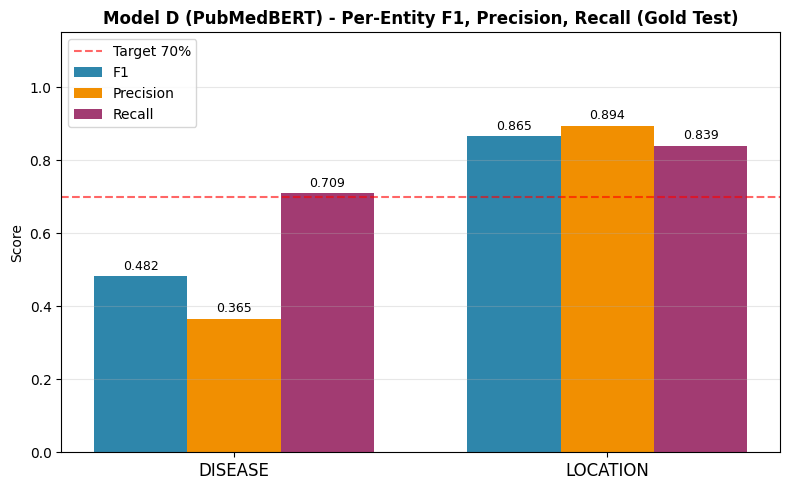

Saved: model_d_per_entity_f1.png


In [18]:
# ============================================================
# VIZ 2: PER-ENTITY F1 BAR CHART
# ============================================================
from seqeval.metrics import f1_score as seq_f1

entity_types = ['DISEASE', 'LOCATION']
entity_f1s, entity_precs, entity_recs = [], [], []

for etype in entity_types:
    # Filter hanya entitas yang relevan
    relevant_labels = [f'B-{etype}', f'I-{etype}']
    filtered_preds = [[l if l in relevant_labels else 'O' for l in seq] for seq in all_gold_preds]
    filtered_trues = [[l if l in relevant_labels else 'O' for l in seq] for seq in all_gold_trues]
    try:
        ef = f1_score(filtered_trues, filtered_preds, average='macro')
        ep = precision_score(filtered_trues, filtered_preds, average='macro')
        er = recall_score(filtered_trues, filtered_preds, average='macro')
    except:
        ef = ep = er = 0.0
    entity_f1s.append(ef)
    entity_precs.append(ep)
    entity_recs.append(er)

x = np.arange(len(entity_types))
width = 0.25

fig, ax = plt.subplots(figsize=(8, 5))
bars_f1   = ax.bar(x - width, entity_f1s,   width, label='F1',        color='#2E86AB')
bars_prec = ax.bar(x,         entity_precs,  width, label='Precision', color='#F18F01')
bars_rec  = ax.bar(x + width, entity_recs,   width, label='Recall',    color='#A23B72')

for bars in [bars_f1, bars_prec, bars_rec]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.01, f'{h:.3f}',
                ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(entity_types, fontsize=12)
ax.set_ylabel('Score')
ax.set_ylim([0, 1.15])
ax.set_title('Model D (PubMedBERT) - Per-Entity F1, Precision, Recall (Gold Test)', fontweight='bold')
ax.axhline(0.70, color='red', linestyle='--', alpha=0.6, label='Target 70%')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}model_d_per_entity_f1.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: model_d_per_entity_f1.png")

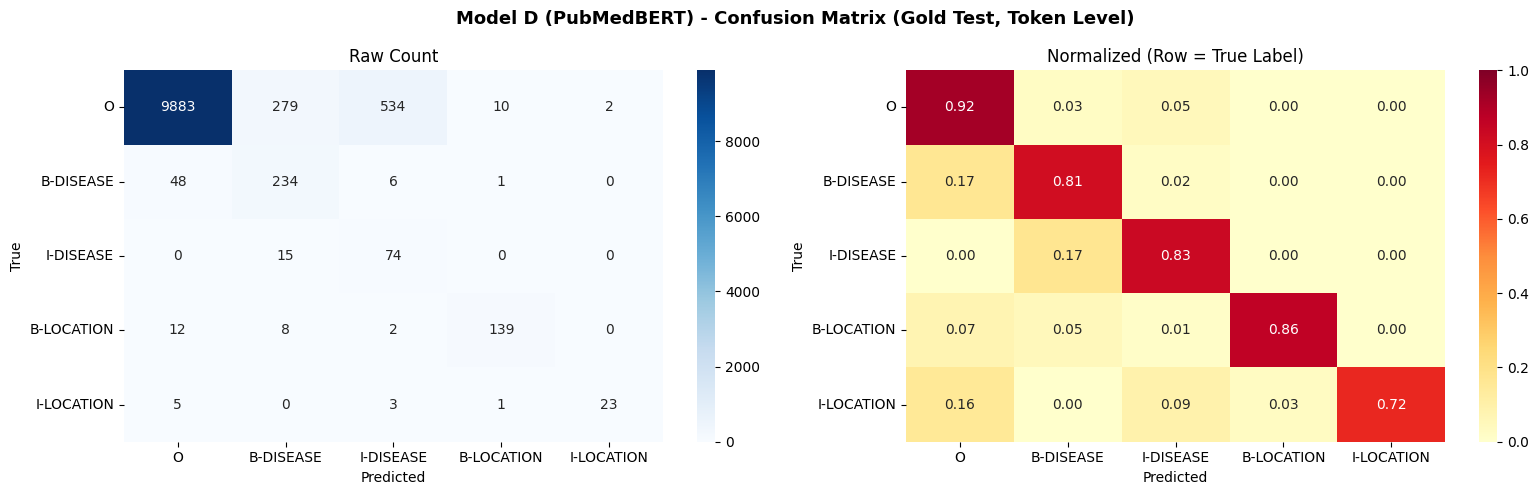

Saved: model_d_confusion_matrix.png


In [19]:
# ============================================================
# VIZ 3: CONFUSION MATRIX (TOKEN LEVEL)
# ============================================================
label_order = ['O', 'B-DISEASE', 'I-DISEASE', 'B-LOCATION', 'I-LOCATION']

cm = confusion_matrix(flat_trues, flat_preds, labels=label_order)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Model D (PubMedBERT) - Confusion Matrix (Gold Test, Token Level)',
             fontsize=13, fontweight='bold')

# Raw count
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_order, yticklabels=label_order, ax=axes[0])
axes[0].set_title('Raw Count')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

# Normalized (row = true)
cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-9)
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='YlOrRd',
            xticklabels=label_order, yticklabels=label_order, ax=axes[1],
            vmin=0, vmax=1)
axes[1].set_title('Normalized (Row = True Label)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}model_d_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: model_d_confusion_matrix.png")

## 10. Error Analysis

In [23]:
# ============================================================
# ERROR ANALYSIS: CONTOH SALAH PREDIKSI
# ============================================================

print("=" * 60)
print("ERROR ANALYSIS - GOLD TEST")
print("=" * 60)

# Kumpulkan error per tipe
error_types = defaultdict(list)  # key: (true, pred), val: list of (sentence, token, pos)
error_sentences = []

for i, (pred_seq, true_seq, (tokens, _)) in enumerate(
        zip(all_gold_preds, all_gold_trues, gold_sentences)):

    sentence_has_error = False
    sentence_errors = []

    min_len = min(len(pred_seq), len(true_seq), len(tokens))
    for j in range(min_len):
        if pred_seq[j] != true_seq[j]:
            sentence_has_error = True
            error_types[(true_seq[j], pred_seq[j])].append(tokens[j])
            sentence_errors.append({
                'token': tokens[j],
                'true': true_seq[j],
                'pred': pred_seq[j]
            })

    if sentence_has_error:
        error_sentences.append({
            'sentence': tokens[:min_len],
            'true':     true_seq[:min_len],
            'pred':     pred_seq[:min_len],
            'errors':   sentence_errors
        })

# --- Ringkasan tipe error ---
print(f"\nTotal kalimat dengan error: {len(error_sentences)} / {len(gold_sentences)}")
print(f"\nTop error types (True → Pred):")
sorted_errors = sorted(error_types.items(), key=lambda x: len(x[1]), reverse=True)
for (true_label, pred_label), tokens_list in sorted_errors[:10]:
    print(f"  {true_label:<15} → {pred_label:<15} : {len(tokens_list):>4}x  "
          f"(contoh: {tokens_list[:3]})")

# --- Contoh kalimat salah prediksi ---
print(f"\n{'='*60}")
print("SAMPLE ERROR SENTENCES (maks 5):")
print('='*60)

for idx, sample in enumerate(error_sentences[:5]):
    print(f"\n[Error Sample {idx+1}]")
    print(f"Token  : {' '.join(sample['sentence'][:20])}")
    print(f"True   : {' '.join(sample['true'][:20])}")
    print(f"Pred   : {' '.join(sample['pred'][:20])}")
    print(f"Errors : {sample['errors']}")

ERROR ANALYSIS - GOLD TEST

Total kalimat dengan error: 188 / 536

Top error types (True → Pred):
  O               → I-DISEASE       :  534x  (contoh: ['a', 'result,', 'in'])
  O               → B-DISEASE       :  279x  (contoh: ['As', 'We', 'fever,'])
  B-DISEASE       → O               :   48x  (contoh: ['(NiV)', 'Virus', '(NiV)'])
  I-DISEASE       → B-DISEASE       :   15x  (contoh: ['Nipah', 'Nipah', 'Nipah,'])
  B-LOCATION      → O               :   12x  (contoh: ['Asian', '(NiV-Malaysia,', 'Province'])
  O               → B-LOCATION      :   10x  (contoh: ['Philippines.', 'India', 'Bangladesh'])
  B-LOCATION      → B-DISEASE       :    8x  (contoh: ['NiV-Malaysia', 'NiV-Bangladesh,', 'NiV-Bangladesh,'])
  B-DISEASE       → I-DISEASE       :    6x  (contoh: ['Nipah', 'encephalitis', 'Nipah'])
  I-LOCATION      → O               :    5x  (contoh: ['of', 'Indian', 'district,'])
  I-LOCATION      → I-DISEASE       :    3x  (contoh: ['African', 'East', 'virus'])

SAMPLE ERROR SENTEN

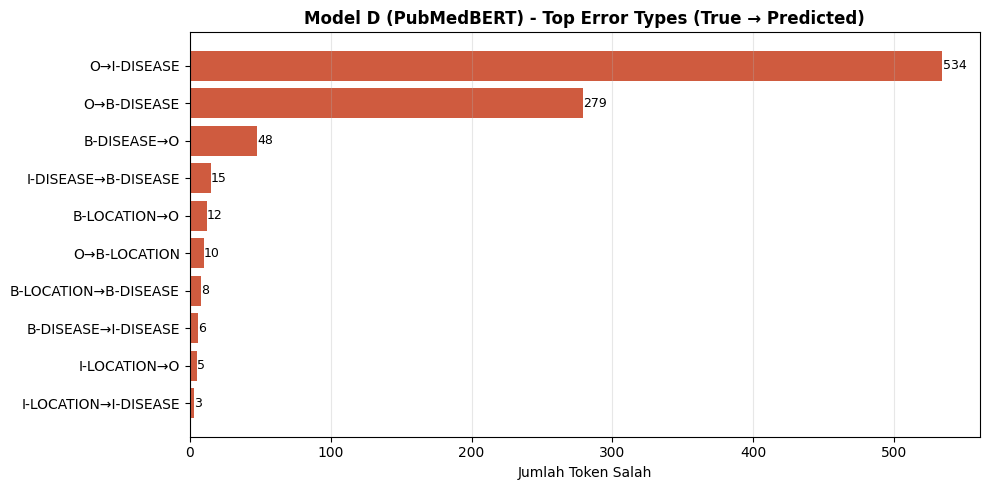

Saved: model_d_error_analysis.png


In [24]:
# ============================================================
# VIZ 4: ERROR TYPE BAR CHART
# ============================================================
if sorted_errors:
    top_n = min(10, len(sorted_errors))
    error_labels = [f"{t}→{p}" for (t, p), _ in sorted_errors[:top_n]]
    error_counts = [len(v) for _, v in sorted_errors[:top_n]]

    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.barh(error_labels[::-1], error_counts[::-1], color='#C73E1D', alpha=0.85)
    for bar, val in zip(bars, error_counts[::-1]):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                str(val), va='center', fontsize=9)
    ax.set_xlabel('Jumlah Token Salah')
    ax.set_title('Model D (PubMedBERT) - Top Error Types (True → Predicted)', fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}model_d_error_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: model_d_error_analysis.png")

## 11. Save Model

In [25]:
# ============================================================
# SAVE RESULTS & ARTIFACTS
# ============================================================

# 1. Save evaluation results ke txt
report_str = classification_report(all_gold_trues, all_gold_preds, digits=4)
with open(f'{OUTPUT_DIR}model_d_gold_test_results.txt', 'w') as f:
    f.write("=" * 60 + "\n")
    f.write("MODEL C - PubMedBERT - GOLD TEST EVALUATION\n")
    f.write("=" * 60 + "\n")
    f.write(f"Model     : {MODEL_NAME}\n")
    f.write(f"Best Epoch: {best_epoch}\n")
    f.write(f"Val F1    : {best_val_f1:.4f}\n")
    f.write(f"Gold F1   : {gold_f1:.4f}\n")
    f.write(f"Gold P    : {gold_prec:.4f}\n")
    f.write(f"Gold R    : {gold_rec:.4f}\n\n")
    f.write(report_str)

# 2. Save config
config = {
    'model_type': 'PubMedBERT',
    'pretrained': MODEL_NAME,
    'num_labels': NUM_LABELS,
    'max_len': MAX_LEN,
    'batch_size': BATCH_SIZE,
    'lr': LR,
    'max_epochs': MAX_EPOCHS,
    'best_epoch': best_epoch,
    'best_val_f1': round(best_val_f1, 4),
    'gold_f1': round(gold_f1, 4),
    'seed': SEED
}
with open(f'{OUTPUT_DIR}model_d_config.json', 'w') as f:
    json.dump(config, f, indent=2)

# 3. Verify
print("=== SAVED FILES ===")
saved_files = [
    'model_d_best/',
    'model_d_checkpoint.pt',
    'model_d_config.json',
    'model_d_gold_test_results.txt',
    'model_d_training_history.png',
    'model_d_per_entity_f1.png',
    'model_d_confusion_matrix.png',
    'model_d_error_analysis.png',
    'model_d_eda_label_distribution.png',
    'model_d_eda_sentence_length.png',
    'model_d_eda_entity_ratio.png',
]
for fname in saved_files:
    path = f'{OUTPUT_DIR}{fname}'
    exists = os.path.exists(path)
    size_str = ''
    if exists and not fname.endswith('/'):
        size_str = f"{os.path.getsize(path)/1024:.1f} KB"
    print(f"  {'✓' if exists else '✗'} {fname:<45} {size_str}")

=== SAVED FILES ===
  ✓ model_d_best/                                 
  ✓ model_d_checkpoint.pt                         4.3 KB
  ✓ model_d_config.json                           0.3 KB
  ✓ model_d_gold_test_results.txt                 0.6 KB
  ✓ model_d_training_history.png                  107.9 KB
  ✓ model_d_per_entity_f1.png                     46.8 KB
  ✓ model_d_confusion_matrix.png                  107.1 KB
  ✓ model_d_error_analysis.png                    63.6 KB
  ✓ model_d_eda_label_distribution.png            91.0 KB
  ✓ model_d_eda_sentence_length.png               63.2 KB
  ✓ model_d_eda_entity_ratio.png                  66.3 KB


## 12. Summary

In [35]:
# ============================================================
# FINAL SUMMARY — MODEL D (PubMedBERT)
# ============================================================
print("\n" + "=" * 60)
print("MODEL D - PubMedBERT - FINAL SUMMARY")
print("=" * 60)
print(f"\nArsitektur : PubMedBERT (uncased, abstract-fulltext)")
print(f"Pretrained : PubMed full-text (trained from scratch)")
print(f"Best Epoch : {best_epoch}")
print(f"\nResults:")
print(f"  Val F1  (silver): {best_val_f1:.4f}")
print(f"  Gold F1 (final) : {gold_f1:.4f}")
print(f"  Gold P          : {gold_prec:.4f}")
print(f"  Gold R          : {gold_rec:.4f}")
print(f"\nGap (Val → Gold) : {best_val_f1 - gold_f1:.4f}")

for m, arch, dom, f1 in comparison:
    marker = ' ← ini' if m == 'D' else ''
    print(f"{m:<7} {arch:<25} {dom:<25} {f1}{marker}")
print("\nModel D selesai! Lanjut ke final_eval.ipynb untuk komparasi A vs B vs C vs D.")



MODEL D - PubMedBERT - FINAL SUMMARY

Arsitektur : PubMedBERT (uncased, abstract-fulltext)
Pretrained : PubMed full-text (trained from scratch)
Best Epoch : 13

Results:
  Val F1  (silver): 0.8864
  Gold F1 (final) : 0.6736
  Gold P          : 0.6294
  Gold R          : 0.7739

Gap (Val → Gold) : 0.2128
A       CharCNN-BiLSTM-CRF        None                      ~41%
B       XLM-RoBERTa               General multilingual      ~56%
C       BioBERT                   Biomedical general        ~56%
D       PubMedBERT                Biomedical specialized    67.4% (actual) ← ini

Model D selesai! Lanjut ke final_eval.ipynb untuk komparasi A vs B vs C vs D.
